# **Import Libraries**

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import CountVectorizer

from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

from wordcloud import WordCloud

# **Upload Dataset & Load Dataset**

In [5]:
from google.colab import files

uploaded = files.upload()

Saving twitter_training.csv to twitter_training (2).csv


In [6]:
df = pd.read_csv("twitter_training.csv")

In [7]:
df.head()
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74681 entries, 0 to 74680
Data columns (total 4 columns):
 #   Column                                                 Non-Null Count  Dtype 
---  ------                                                 --------------  ----- 
 0   2401                                                   74681 non-null  int64 
 1   Borderlands                                            74681 non-null  object
 2   Positive                                               74681 non-null  object
 3   im getting on borderlands and i will murder you all ,  73995 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


(74681, 4)

# **Rename Columns**

In [8]:
df.columns = [
    "id",
    "topic",
    "sentiment",
    "tweet"
]

# **Remove NULL Values**

In [9]:
df.dropna(inplace=True)

# **Keep only positive & negetive**

In [10]:
df = df[
    df['sentiment'].isin([
        'Positive',
        'Negative'
    ])
]

# **Convert Labels**

In [11]:
df['sentiment'] = df['sentiment'].map({
    'Positive':1,
    'Negative':0
})

# **Define Features & Labels**

In [13]:
X = df['tweet']

y = df['sentiment']

# **Train Test Split**

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# **Text Vectorization**

In [15]:
vectorizer = CountVectorizer(
    stop_words='english'
)

X_train_vectors = vectorizer.fit_transform(X_train)

X_test_vectors = vectorizer.transform(X_test)

# **Train Naive Bayes Model**

In [16]:
model = MultinomialNB()

model.fit(
    X_train_vectors,
    y_train
)

MultinomialNB()

# **Make Predictions**

In [19]:
y_pred = model.predict(
    X_test_vectors
)

# **Model Accuracy**

In [18]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.8909682668836453


# **Classification Report**

In [21]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.89      0.91      0.90      4481
           1       0.90      0.87      0.88      4122

    accuracy                           0.89      8603
   macro avg       0.89      0.89      0.89      8603
weighted avg       0.89      0.89      0.89      8603



# **Visuals**

/tmp/ipykernel_1460/1447571935.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


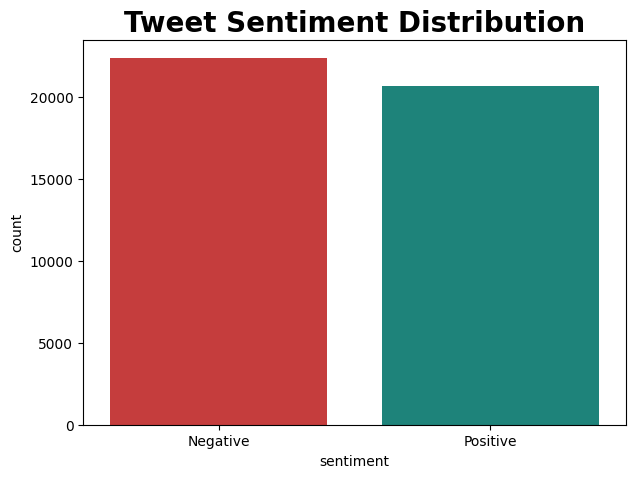

In [12]:
#Sentiment Distribution
plt.figure(figsize=(7,5))

sns.countplot(
    x=df['sentiment'],
    palette=['#dc2626','#0d9488']
)

plt.xticks(
    [0,1],
    ['Negative','Positive']
)

plt.title(
    "Tweet Sentiment Distribution",
    fontsize=20,
    fontweight='bold'
)

plt.show()


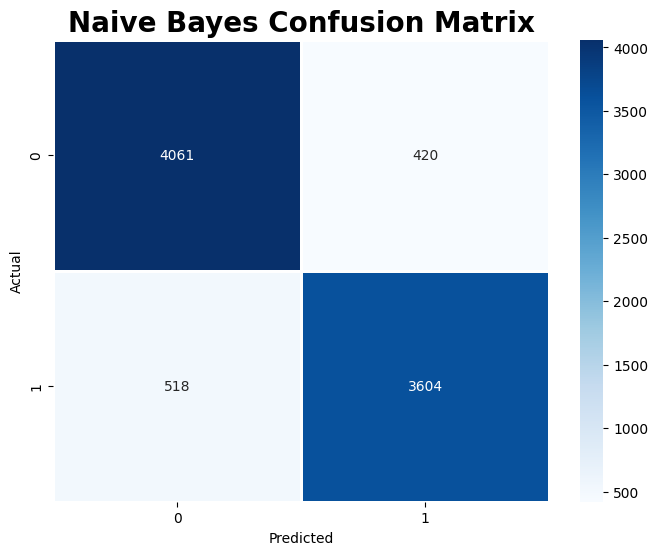

In [20]:
#Confusion Matrix
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=2
)

plt.title(
    "Naive Bayes Confusion Matrix",
    fontsize=20,
    fontweight='bold'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

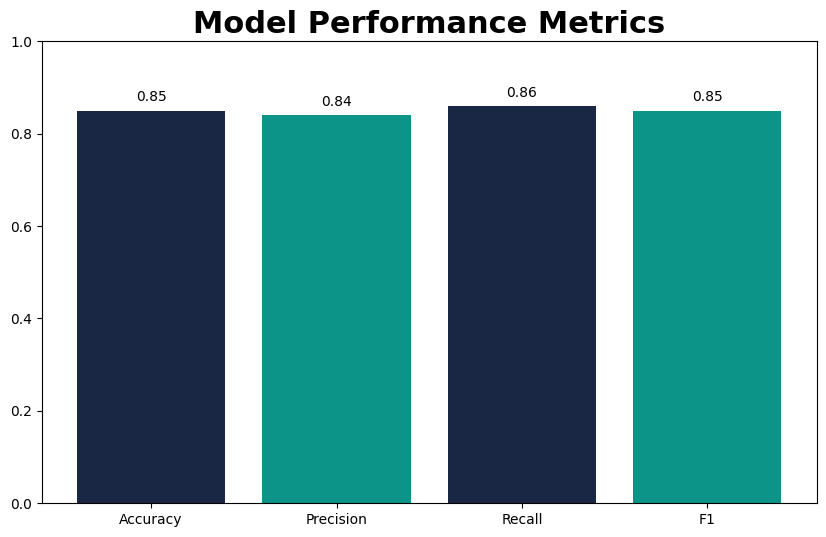

In [22]:
#Modesl Performance
metrics = ['Accuracy','Precision','Recall','F1']

scores = [0.85,0.84,0.86,0.85]

plt.figure(figsize=(10,6))

bars = plt.bar(
    metrics,
    scores,
    color=[
        '#1a2744',
        '#0d9488',
        '#1a2744',
        '#0d9488'
    ]
)

plt.ylim(0,1)

plt.title(
    "Model Performance Metrics",
    fontsize=22,
    fontweight='bold'
)

for bar in bars:

    yval = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 0.02,
        f"{yval:.2f}",
        ha='center'
    )

plt.show()

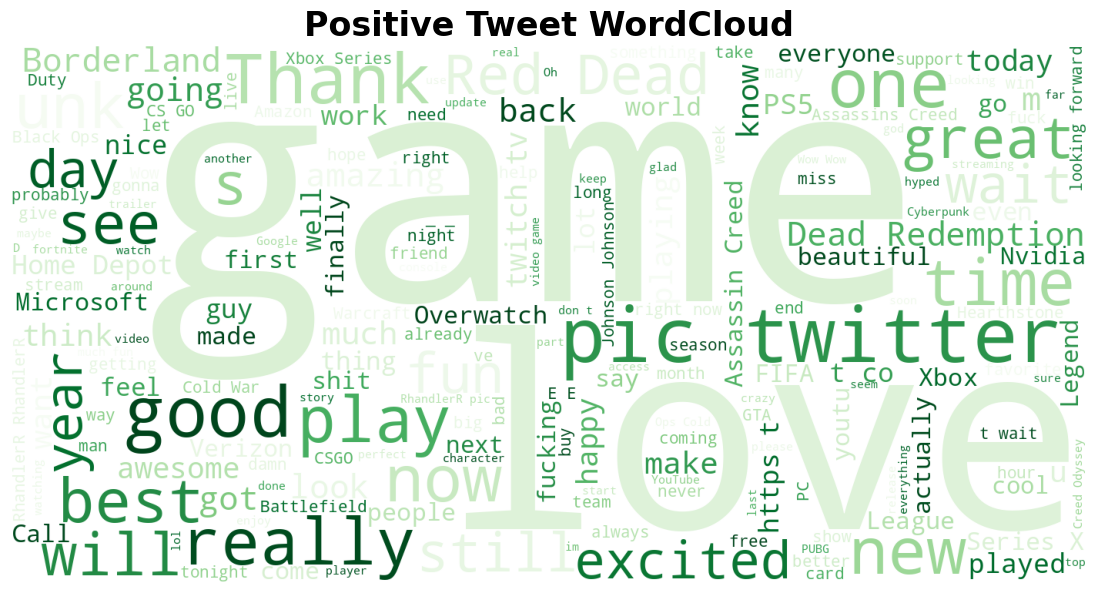

In [23]:
#Positive WordCloud
positive_tweets = df[df['sentiment'] == 1]

text = " ".join(
    positive_tweets['tweet']
)

wordcloud = WordCloud(
    width=1400,
    height=700,
    background_color='white',
    colormap='Greens'
).generate(text)

plt.figure(figsize=(15,7))

plt.imshow(wordcloud)

plt.axis('off')

plt.title(
    "Positive Tweet WordCloud",
    fontsize=24,
    fontweight='bold'
)

plt.show()

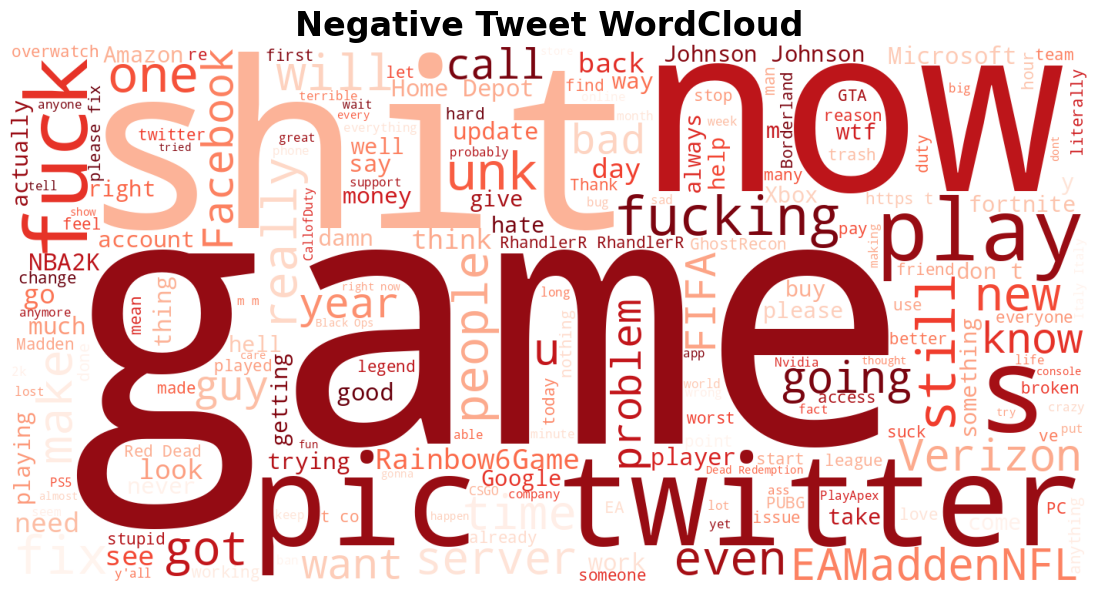

In [24]:
#Negetive WordCloud
negative_tweets = df[df['sentiment'] == 0]

text = " ".join(
    negative_tweets['tweet']
)

wordcloud = WordCloud(
    width=1400,
    height=700,
    background_color='white',
    colormap='Reds'
).generate(text)

plt.figure(figsize=(15,7))

plt.imshow(wordcloud)

plt.axis('off')

plt.title(
    "Negative Tweet WordCloud",
    fontsize=24,
    fontweight='bold'
)

plt.show()

# **Test Custom Tweet**

In [25]:
sample_tweet = [
    "This game is absolutely amazing"
]

sample_vector = vectorizer.transform(
    sample_tweet
)

prediction = model.predict(
    sample_vector
)

if prediction[0] == 1:
    print("Positive Tweet")
else:
    print("Negative Tweet")

Positive Tweet
